In [ ]:
import os 
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")

In [ ]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from scipy.stats import t
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min
import plotly.graph_objects as go
from utils.ph import *
import pandas as pd
from models.phVAE import *
from steps.model_training import *

In [3]:
df = pd.read_csv('data/unigram_freq.csv')

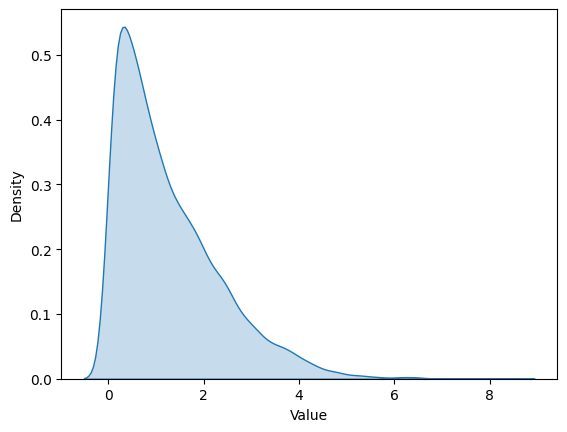

In [4]:
data_original = df.head(10000)['count'].to_numpy().astype(np.int64)

data = np.log(data_original) 
min_value = np.min(data)
data = data - min_value

sns.kdeplot(data, fill=True,)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()
# creating the dataset
tensor_x = torch.tensor(data, dtype=torch.float32).view(-1, 1)
dataset = TensorDataset(tensor_x)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

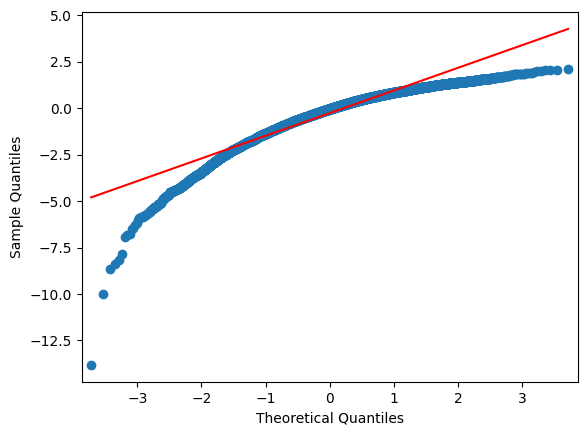

In [5]:
import statsmodels.api as sm
sm.qqplot(np.log(data+1e-6), line='s')
plt.show()


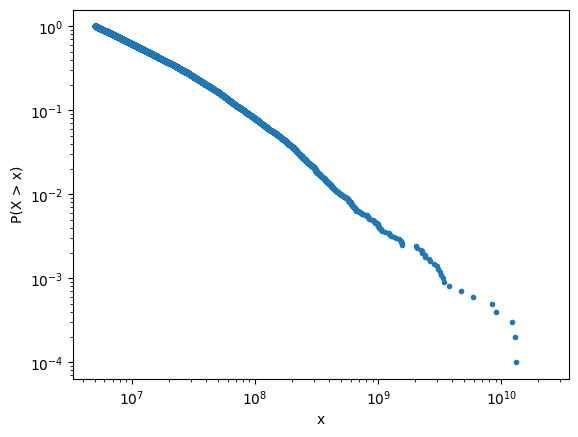

In [6]:
x = np.sort(data_original)
ccdf = 1.0 - np.arange(1, len(x)+1) / len(x)

plt.loglog(x, ccdf, marker='.', linestyle='none')
plt.xlabel("x")
plt.ylabel("P(X > x)")
plt.show()

# PHVAE

In [7]:
model= FeedForwardPHVAE(input_dim=1, latent_dim=5, n_phases=15)
train_phvae(
    model,
    train_loader,
    epochs=13,
    learning_rate=1e-2,
    beta=1,           
    grad_clip=1.0,
    save_every=10,
    reduce_lr=False,
)

/home/hakimmics/myenv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
Epoch 1/13: 100%|██████████| 40/40 [00:09<00:00,  4.06it/s]


Epoch 001 | Loss: 1.3175 | Recon: -1.2325 | KL: 0.0850 | Time/epoch: 9.85s


Epoch 2/13: 100%|██████████| 40/40 [00:09<00:00,  4.20it/s]


Epoch 002 | Loss: 1.2212 | Recon: -1.2202 | KL: 0.0010 | Time/epoch: 9.52s


Epoch 3/13: 100%|██████████| 40/40 [00:09<00:00,  4.33it/s]


...

Epoch 011 | Loss: 1.2199 | Recon: -1.2198 | KL: 0.0000 | Time/epoch: 9.85s


Epoch 12/13: 100%|██████████| 40/40 [00:08<00:00,  4.60it/s]


Epoch 012 | Loss: 1.2189 | Recon: -1.2189 | KL: 0.0000 | Time/epoch: 8.71s


Epoch 13/13: 100%|██████████| 40/40 [00:08<00:00,  4.45it/s]

Epoch 013 | Loss: 1.2189 | Recon: -1.2189 | KL: 0.0000 | Time/epoch: 8.99s

Total training time: 119.52s (9.19s/epoch avg)
Mean time/epoch: 9.19 ± 0.59 s


In [8]:
model.eval()
N = data.shape[0]
device = next(model.parameters()).device
with torch.no_grad():
    # sample latents
    z = torch.randn(N, model.latent_dim, device=device)
    alpha, T, t = model.decode_params(z) 
    ph_samples = ph_sample_batch(alpha, T, t).cpu().numpy()

#
# reset data transformation
data_real = np.exp(data + min_value)
ph_samples = np.exp(ph_samples + min_value)
# trim ph_samples to be within data range
#

n_bins= 10000
hist_data = go.Histogram(
    x=data_real,
    name='Real Data',
    opacity=0.7,
    nbinsx=n_bins,  
    marker_color='#4C72B0'
)

# Create histogram for ph_samples
hist_samples = go.Histogram(
    x=ph_samples,
    name='PH Samples',
    opacity=0.7,
    nbinsx=n_bins,
    marker_color='#DD8452'
)

# Combine them
fig = go.Figure(data=[hist_data, hist_samples])

# Update layout for a publication-ready style
fig.update_layout(
    title_text="PH-VAE generations vs Weibull",
    title_font_size=30,
    #xaxis_title="x",
    #yaxis_title="Density",
    yaxis_type="log",  # Set y-axis to log scale
    font=dict(
        family="serif",  # Use a serif font
        size=30,         # Base font size
        color="black"
    ),
    legend=dict(
        x=0.98, # Place legend in top right corner
        y=0.98,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.7)', # Semi-transparent background
        bordercolor='black',
        borderwidth=1,
        font_size=30
    ),
    plot_bgcolor='white', # White background
    # Remove fixed width/height to allow scalable export
    # width=800,
    # height=500,
    margin=dict(l=50, r=20, t=50, b=50) # Adjust margins
)

# Add prominent axis lines and updated gridlines
fig.update_xaxes(
    showline=True,  # Show x-axis line
    linewidth=1.5,
    linecolor='black',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(200, 200, 200, 0.5)' # Lighter gray grid
)
fig.update_yaxes(
    showline=True,  # Show y-axis line
    linewidth=1.5,
    linecolor='black',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(200, 200, 200, 0.5)' # Lighter gray grid
)

fig.write_html('/home/hakimmics/figures/word_freq_phvae.html')

In [9]:
def empirical_quantiles(x):
    return {
        "q95": np.quantile(x, 0.95),
        "q99": np.quantile(x, 0.99),
        "q995": np.quantile(x, 0.995),
    }

emp_q = empirical_quantiles(data)
def ks_distance(data, model_samples):
    data = np.sort(data)
    model_samples = np.sort(model_samples)

    # Empirical CDFs
    F_data = np.arange(1, len(data)+1) / len(data)
    F_model = np.arange(1, len(model_samples)+1) / len(model_samples)

    # Interpolate model CDF on data points
    F_model_interp = np.interp(data, model_samples, F_model)

    return np.max(np.abs(F_data - F_model_interp))


def ks_tail(data, model_samples, q=0.95):
    thr = np.quantile(data, q)

    d_tail = data[data >= thr]
    m_tail = model_samples[model_samples >= thr]

    if len(m_tail) == 0:
        return np.nan

    # Conditional CDFs (renormalized)
    d_tail = np.sort(d_tail)
    m_tail = np.sort(m_tail)

    Fd = np.arange(1, len(d_tail)+1) / len(d_tail)
    Fm = np.arange(1, len(m_tail)+1) / len(m_tail)

    Fm_interp = np.interp(d_tail, m_tail, Fm)

    return np.max(np.abs(Fd - Fm_interp))
def quantile_errors(data, model_samples):
    q_data = empirical_quantiles(data)
    q_mod = empirical_quantiles(model_samples)

    return {
        "q95_err": (q_mod["q95"] - q_data["q95"]) / q_data["q95"],
        "q99_err": (q_mod["q99"] - q_data["q99"]) / q_data["q99"],
        "q995_err": (q_mod["q995"] - q_data["q995"]) / q_data["q995"],
    }
results = {
    "KS_full": ks_distance(data, ph_samples),
    "KS_tail": ks_tail(data, ph_samples, q=0.95),
}
results.update(quantile_errors(data, ph_samples))

print("\n=== Results for model ===")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")



=== Results for model ===
KS_full   : 0.9999
KS_tail   : 0.9999
q95_err   : 42015541.8599
q99_err   : 111868559.5967
q995_err  : 168956362.0722


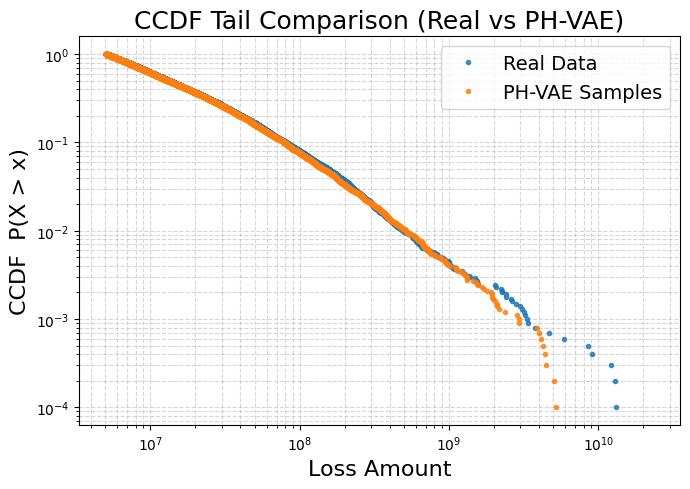

In [10]:
def ccdf_curve(x):
    """Return sorted values and CCDF for plotting."""
    x_sorted = np.sort(x)
    n = len(x_sorted)
    ccdf = 1.0 - np.arange(1, n+1) / n
    return x_sorted, ccdf
# Real data CCDF
x_real, ccdf_real = ccdf_curve(data_real)

# PH-VAE samples CCDF
x_ph, ccdf_ph = ccdf_curve(ph_samples)
plt.figure(figsize=(7,5))

# Plot real data CCDF
plt.loglog(
    x_real, ccdf_real,
    marker='.', linestyle='none',
    label="Real Data",
    alpha=0.8
)

# Plot PH-VAE CCDF
plt.loglog(
    x_ph, ccdf_ph,
    marker='.', linestyle='none',
    label="PH-VAE Samples",
    alpha=0.8
)

plt.xlabel("Loss Amount", fontsize=16)
plt.ylabel("CCDF  P(X > x)", fontsize=16)
plt.title("CCDF Tail Comparison (Real vs PH-VAE)", fontsize=18)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


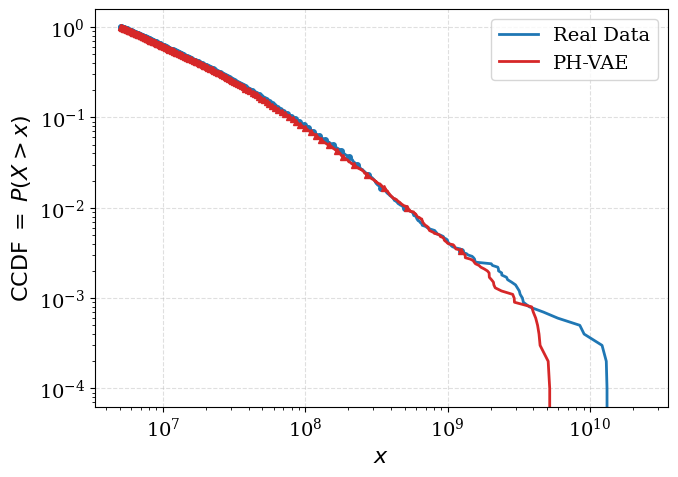

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.size']   = 14
rcParams['lines.linewidth'] = 2.0

def ccdf_curve(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    ccdf = 1.0 - np.arange(1, n+1) / n
    return x_sorted, ccdf

# Compute curves
x_real, ccdf_real = ccdf_curve(data_real)
x_ph,   ccdf_ph   = ccdf_curve(ph_samples)

plt.figure(figsize=(7,5))

# --- Real data ---
step = max(1, len(x_real) // 150)  # ≈150 markers max
plt.loglog(
    x_real, ccdf_real,
    color="#1f77b4",
    label="Real Data"
)
plt.loglog(
    x_real[::step], ccdf_real[::step],
    marker='o', linestyle='none', markersize=4, color="#1f77b4"
)

# --- PH-VAE ---
step2 = max(1, len(x_ph) // 150)
plt.loglog(
    x_ph, ccdf_ph,
    color="#d62728",
    label="PH-VAE"
)
plt.loglog(
    x_ph[::step2], ccdf_ph[::step2],
    marker='^', linestyle='none', markersize=4, color="#d62728"
)

plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$\mathrm{CCDF}\;=\;P(X>x)$", fontsize=16)
plt.grid(True, which="major", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# VAE

In [12]:
config = {
        "input_dim": 1,
        "latent_dim": 2,
        "batch_size": 128,
        "epochs": 100,
        "learning_rate": 1e-4,
        "model_name": "vae classic",
        'verbose': False
    }
class FeedForwardVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=256):
        super(FeedForwardVAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder layers: fully connected
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder layers: fully connected
        self.fc_decode = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc_decode(z))
        h = F.relu(self.fc_decode2(h))
        reconstruction = self.fc_out(h)
        return reconstruction

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction
    
def vae_loss(recon_x, x, mu, logvar, input_dim):
    BCE = F.mse_loss(recon_x.view(-1, input_dim), x.view(-1, input_dim), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE +1 * KLD, BCE, KLD
model = FeedForwardVAE(config["input_dim"], config["latent_dim"])

optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

for epoch in range(config['epochs']):
    model.train()
    if epoch % 10 == 0 and epoch > 0:
        # reduce the learning rate
        for param_group in optimizer.param_groups:
            param_group['lr'] = param_group['lr'] * 0.1
        print(f"Learning rate reduced to {param_group['lr']}")
    
    total_gen_loss = 0
    for batch_idx, (x) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch + 1}/{config['epochs']}")):
        x = x[0]
        # ========== Forward through Encoder + Decoder ==========
        recon_x = model(x)
        mu, logvar = model.encode(x)
        
        
        total_loss, recon_loss, kl_loss =  vae_loss(recon_x, x, mu, logvar, input_dim=config['input_dim'])
        optimizer.zero_grad()
        total_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    if epoch % 10==0:
        # save the model 
        torch.save(model.state_dict(), f"vae_1d_v.pth")
        
    print(f"Epoch {epoch + 1}, Total Loss: {total_loss.item():.4f}, Recon Loss: {recon_loss.item():.4f}, KL Loss: {kl_loss.item():.4f}")
    


Epoch 1/100: 100%|██████████| 40/40 [00:00<00:00, 99.92it/s] 


Epoch 1, Total Loss: 32.0254, Recon Loss: 24.5735, KL Loss: 7.4519


Epoch 2/100: 100%|██████████| 40/40 [00:00<00:00, 92.56it/s] 


Epoch 2, Total Loss: 24.7845, Recon Loss: 15.8644, KL Loss: 8.9201


Epoch 3/100: 100%|██████████| 40/40 [00:00<00:00, 132.08it/s]


...

Epoch 98, Total Loss: 17.3602, Recon Loss: 9.5845, KL Loss: 7.7757


Epoch 99/100: 100%|██████████| 40/40 [00:00<00:00, 108.23it/s]


Epoch 99, Total Loss: 16.9456, Recon Loss: 9.0355, KL Loss: 7.9101


Epoch 100/100: 100%|██████████| 40/40 [00:00<00:00, 114.58it/s]

Epoch 100, Total Loss: 11.6580, Recon Loss: 7.4571, KL Loss: 4.2009


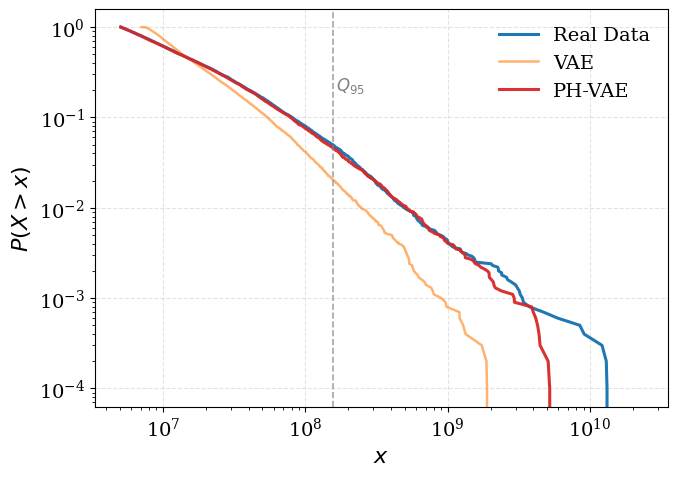

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- ICML-style params ---
rcParams['font.family'] = 'serif'
rcParams['font.size']   = 14
rcParams['lines.linewidth'] = 2.2

def ccdf_curve(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    ccdf = 1.0 - np.arange(1, n+1) / n
    return x_sorted, ccdf

# --- Samples ---
vae_samples = model.decode(
    torch.randn(len(data_real), config["latent_dim"])
).detach().numpy().flatten()
vae_samples = np.exp(vae_samples + min_value)
x_real, ccdf_real = ccdf_curve(data_real)
x_ph,   ccdf_ph   = ccdf_curve(ph_samples)
x_vae,  ccdf_vae  = ccdf_curve(vae_samples)

plt.figure(figsize=(7,5))

# --- Real data (reference) ---
step = max(1, len(x_real)//120)
plt.loglog(x_real, ccdf_real, color="#1f77b4", label="Real Data")
# plt.loglog(
#     x_real[::step], ccdf_real[::step],
#     linestyle="none", marker="o", markersize=4,
#     color="#1f77b4"
# )

# --- VAE (baseline, de-emphasized but visible) ---
plt.loglog(
    x_vae, ccdf_vae,
    color="#ff7f0e",
    alpha=0.6,
    linewidth=1.8,
    label="VAE"
)

# --- PH-VAE (hero) ---
step2 = max(1, len(x_ph)//120)
plt.loglog(x_ph,ccdf_ph, alpha=0.95, color="#d62728", label="PH-VAE")
# plt.loglog(
#     x_ph[::step2], ccdf_ph[::step2],
#     linestyle="none", marker="^", markersize=4,
#     color="#d62728"
# )

# --- Tail marker (NO zooming) ---
q95 = np.quantile(data_real, 0.95)
plt.axvline(
    q95, color="gray", linestyle="--", linewidth=1.2, alpha=0.7
)
plt.text(
    q95*1.05, 2e-1, r"$Q_{95}$",
    fontsize=12, color="gray"
)

plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$P(X > x)$", fontsize=16)

plt.grid(True, which="major", linestyle="--", alpha=0.35)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [14]:
# %%
# Quantile table + CVaR table for:
#   data_real   = true data on original scale
#   ph_samples  = PH-VAE generated samples on original scale
#   vae_samples = Gaussian-VAE generated samples on original scale
#
# Assumes these 3 arrays already exist from your notebook.

import numpy as np
import pandas as pd

x_true = np.asarray(data_real).reshape(-1)
x_ph   = np.asarray(ph_samples).reshape(-1)
x_vae  = np.asarray(vae_samples).reshape(-1)

# optional safety: keep only finite positive values
mask_true = np.isfinite(x_true) & (x_true > 0)
mask_ph   = np.isfinite(x_ph) & (x_ph > 0)
mask_vae  = np.isfinite(x_vae) & (x_vae > 0)

x_true = x_true[mask_true]
x_ph   = x_ph[mask_ph]
x_vae  = x_vae[mask_vae]

# -----------------------------
# Helpers
# -----------------------------
def cvar(x, q):
    u = np.quantile(x, q)
    tail = x[x >= u]
    if len(tail) == 0:
        return np.nan
    return tail.mean()

# -----------------------------
# Quantile table
# -----------------------------
q_grid = np.array([0.90, 0.95, 0.98, 0.99, 0.995, 0.999])

q_true = np.array([np.quantile(x_true, q) for q in q_grid])
q_ph   = np.array([np.quantile(x_ph, q)   for q in q_grid])
q_vae  = np.array([np.quantile(x_vae, q)  for q in q_grid])

quantile_table = pd.DataFrame({
    "q": q_grid,
    "True_Q": q_true,
    "PH_Q": q_ph,
    "VAE_Q": q_vae,
    "PH_abs_err": np.abs(q_ph - q_true),
    "VAE_abs_err": np.abs(q_vae - q_true),
    "PH_rel_err": np.abs(q_ph - q_true) / (q_true + 1e-12),
    "VAE_rel_err": np.abs(q_vae - q_true) / (q_true + 1e-12),
})

# -----------------------------
# CVaR / Expected shortfall table
# -----------------------------
cvar_grid = np.array([0.95, 0.99, 0.995])

cvar_true = np.array([cvar(x_true, q) for q in cvar_grid])
cvar_ph   = np.array([cvar(x_ph, q)   for q in cvar_grid])
cvar_vae  = np.array([cvar(x_vae, q)  for q in cvar_grid])

cvar_table = pd.DataFrame({
    "q": cvar_grid,
    "True_CVaR": cvar_true,
    "PH_CVaR": cvar_ph,
    "VAE_CVaR": cvar_vae,
    "PH_abs_err": np.abs(cvar_ph - cvar_true),
    "VAE_abs_err": np.abs(cvar_vae - cvar_true),
    "PH_rel_err": np.abs(cvar_ph - cvar_true) / (cvar_true + 1e-12),
    "VAE_rel_err": np.abs(cvar_vae - cvar_true) / (cvar_true + 1e-12),
})

print("\n=== Quantile table ===")
print(quantile_table.to_string(index=False))

print("\n=== CVaR table ===")
print(cvar_table.to_string(index=False))


=== Quantile table ===
    q       True_Q         PH_Q        VAE_Q   PH_abs_err  VAE_abs_err  PH_rel_err  VAE_rel_err
0.900 8.069645e+07 7.877751e+07 5.417004e+07 1.918933e+06 2.652640e+07    0.023780     0.328718
0.950 1.552560e+08 1.438815e+08 8.764980e+07 1.137446e+07 6.760618e+07    0.073263     0.435450
0.980 3.061100e+08 3.056079e+08 1.588987e+08 5.021122e+05 1.472112e+08    0.001640     0.480910
0.990 5.016551e+08 5.142957e+08 2.457775e+08 1.264052e+07 2.558776e+08    0.025198     0.510067
0.995 8.833512e+08 8.723435e+08 4.036243e+08 1.100776e+07 4.797269e+08    0.012461     0.543076
0.999 3.350099e+09 2.930709e+09 9.028734e+08 4.193902e+08 2.447225e+09    0.125187     0.730494

=== CVaR table ===
    q    True_CVaR      PH_CVaR     VAE_CVaR   PH_abs_err  VAE_abs_err  PH_rel_err  VAE_rel_err
0.950 5.996618e+08 4.723624e+08 2.204720e+08 1.272994e+08 3.791898e+08    0.212285     0.632339
0.990 1.978006e+09 1.362930e+09 5.609589e+08 6.150763e+08 1.417048e+09    0.310958     0.716

In [15]:
# Multi-seed summary of Quantile/CVaR metrics in mean +- std format
# Uses bootstrap resampling of existing PH and VAE samples for seed-wise variability.

import numpy as np
import pandas as pd

# -----------------------------
# Config
# -----------------------------
seeds = [0, 1, 2, 3, 4, 5]
q_grid = np.array([0.90, 0.95, 0.98, 0.99, 0.995, 0.999])
cvar_grid = np.array([0.95, 0.99, 0.995])

# -----------------------------
# Inputs and safety filtering
# -----------------------------
x_true = np.asarray(data_real).reshape(-1)
x_ph_base = np.asarray(ph_samples).reshape(-1)
x_vae_base = np.asarray(vae_samples).reshape(-1)

mask_true = np.isfinite(x_true) & (x_true > 0)
mask_ph = np.isfinite(x_ph_base) & (x_ph_base > 0)
mask_vae = np.isfinite(x_vae_base) & (x_vae_base > 0)

x_true = x_true[mask_true]
x_ph_base = x_ph_base[mask_ph]
x_vae_base = x_vae_base[mask_vae]

if len(x_true) == 0 or len(x_ph_base) == 0 or len(x_vae_base) == 0:
    raise ValueError("One of data_real/ph_samples/vae_samples is empty after filtering.")

# -----------------------------
# Helpers
# -----------------------------
def cvar(x, q):
    u = np.quantile(x, q)
    tail = x[x >= u]
    if len(tail) == 0:
        return np.nan
    return float(np.mean(tail))

def one_run_metrics(x_true, x_ph, x_vae):
    q_true = np.array([np.quantile(x_true, q) for q in q_grid])
    q_ph = np.array([np.quantile(x_ph, q) for q in q_grid])
    q_vae = np.array([np.quantile(x_vae, q) for q in q_grid])

    c_true = np.array([cvar(x_true, q) for q in cvar_grid])
    c_ph = np.array([cvar(x_ph, q) for q in cvar_grid])
    c_vae = np.array([cvar(x_vae, q) for q in cvar_grid])

    quantile_df = pd.DataFrame({
        "q": q_grid,
        "True_Q": q_true,
        "PH_Q": q_ph,
        "VAE_Q": q_vae,
        "PH_abs_err": np.abs(q_ph - q_true),
        "VAE_abs_err": np.abs(q_vae - q_true),
        "PH_rel_err": np.abs(q_ph - q_true) / (q_true + 1e-12),
        "VAE_rel_err": np.abs(q_vae - q_true) / (q_true + 1e-12),
    })

    cvar_df = pd.DataFrame({
        "q": cvar_grid,
        "True_CVaR": c_true,
        "PH_CVaR": c_ph,
        "VAE_CVaR": c_vae,
        "PH_abs_err": np.abs(c_ph - c_true),
        "VAE_abs_err": np.abs(c_vae - c_true),
        "PH_rel_err": np.abs(c_ph - c_true) / (c_true + 1e-12),
        "VAE_rel_err": np.abs(c_vae - c_true) / (c_true + 1e-12),
    })

    return quantile_df, cvar_df

def bootstrap_with_seed(x, n, seed):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=n)
    return x[idx]

def mean_std_table(dfs, key_cols):
    cat = pd.concat(dfs, keys=range(len(dfs)), names=["seed_id"])
    num_cols = [c for c in dfs[0].columns if c not in key_cols]

    mean_df = cat.groupby(level=1)[num_cols].mean()
    std_df = cat.groupby(level=1)[num_cols].std(ddof=1)

    out = dfs[0][key_cols].copy()
    for col in num_cols:
        out[col] = [f"{m:.6e} +- {s:.6e}" for m, s in zip(mean_df[col], std_df[col])]
    return out

# -----------------------------
# Multi-seed evaluation
# -----------------------------
quantile_runs = []
cvar_runs = []

n_eval = len(x_true)
for seed in seeds:
    # Seed-wise variability via bootstrap resampling of generated samples
    x_ph_seed = bootstrap_with_seed(x_ph_base, n_eval, seed)
    x_vae_seed = bootstrap_with_seed(x_vae_base, n_eval, 10_000 + seed)

    q_df, c_df = one_run_metrics(x_true, x_ph_seed, x_vae_seed)
    quantile_runs.append(q_df)
    cvar_runs.append(c_df)

quantile_mean_std = mean_std_table(quantile_runs, key_cols=["q"])
cvar_mean_std = mean_std_table(cvar_runs, key_cols=["q"])

print(f"Seeds used: {seeds}")
print("\n=== Quantile table (mean +- std across seeds) ===")
print(quantile_mean_std.to_string(index=False))

print("\n=== CVaR table (mean +- std across seeds) ===")
print(cvar_mean_std.to_string(index=False))

Seeds used: [0, 1, 2, 3, 4, 5]

=== Quantile table (mean +- std across seeds) ===
    q                       True_Q                         PH_Q                        VAE_Q                   PH_abs_err                  VAE_abs_err                   PH_rel_err                  VAE_rel_err
0.900 8.069645e+07 +- 0.000000e+00 7.818392e+07 +- 3.023128e+06 5.413618e+07 +- 1.662418e+06 3.128797e+06 +- 2.228770e+06 2.656027e+07 +- 1.662418e+06 3.877243e-02 +- 2.761919e-02 3.291380e-01 +- 2.060088e-02
0.950 1.552560e+08 +- 0.000000e+00 1.452065e+08 +- 4.462901e+06 8.768871e+07 +- 2.511700e+06 1.004951e+07 +- 4.462901e+06 6.756727e+07 +- 2.511700e+06 6.472863e-02 +- 2.874544e-02 4.351991e-01 +- 1.617780e-02
0.980 3.061100e+08 +- 0.000000e+00 3.149259e+08 +- 1.410628e+07 1.581155e+08 +- 5.420035e+06 1.284648e+07 +- 9.706382e+06 1.479945e+08 +- 5.420035e+06 4.196687e-02 +- 3.170881e-02 4.834685e-01 +- 1.770617e-02
0.990 5.016551e+08 +- 0.000000e+00 5.391270e+08 +- 4.062421e+07 2.433426e+08 +- 1.